In [86]:
from datascience import *
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [87]:
heights = Table.read_table("family_heights.csv")
heights.show(5)

family,father,mother,child,children,order,sex
1,78.5,67,73.2,4,1,male
1,78.5,67,69.2,4,2,female
1,78.5,67,69,4,3,female
1,78.5,67,69,4,4,female
2,75.5,66.5,73.5,4,1,male


In [88]:
heights = heights.with_column("parent_average", (heights.column("father") + heights.column("mother"))/2)

In [89]:
heights

family,father,mother,child,children,order,sex,parent_average
1,78.5,67,73.2,4,1,male,72.75
1,78.5,67,69.2,4,2,female,72.75
1,78.5,67,69,4,3,female,72.75
1,78.5,67,69,4,4,female,72.75
2,75.5,66.5,73.5,4,1,male,71
2,75.5,66.5,72.5,4,2,male,71
2,75.5,66.5,65.5,4,3,female,71
2,75.5,66.5,65.5,4,4,female,71
3,75,64,71,2,1,male,69.5
3,75,64,68,2,2,female,69.5


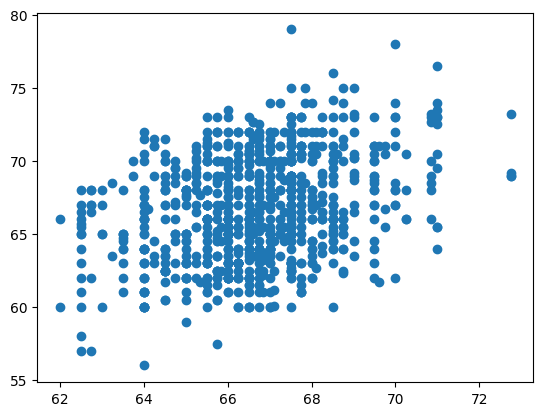

In [90]:
plt.scatter(heights.column("parent_average"), heights.column("child"))

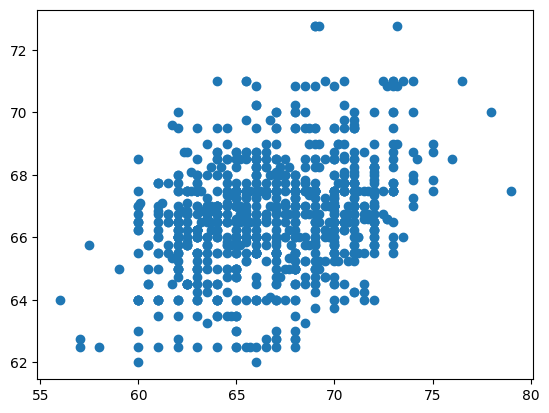

In [91]:
plt.scatter(heights.column("child"), heights.column("parent_average"))

In [92]:
my_height = 5*12+11
spouse_height = 5*12+7

In [93]:
our_average = (my_height + spouse_height) / 2
our_average

69.0

In [94]:
window = 1
def similar_child_heights(parent_average):
    lower_bound = parent_average - window
    upper_bound = parent_average + window
    return (
        heights
        .where("parent_average", are.between(lower_bound, upper_bound))
        .column("child")
    )

heights.where("parent_average", are.between(68, 70)).column("child").mean()

67.799310344827589

In [95]:
def predict_child_height(parent_average):
    return np.mean(similar_child_heights(parent_average=parent_average))

In [96]:
predict_child_height(our_average)

67.799310344827589

In [97]:
similar = similar_child_heights(parent_average=our_average)
predicted_height = predict_child_height(our_average)

In [98]:
heights = heights.with_column("predicted" , heights.apply(predict_child_height, "parent_average"))

In [99]:
heights

family,father,mother,child,children,order,sex,parent_average,predicted
1,78.5,67,73.2,4,1,male,72.75,70.1
1,78.5,67,69.2,4,2,female,72.75,70.1
1,78.5,67,69,4,3,female,72.75,70.1
1,78.5,67,69,4,4,female,72.75,70.1
2,75.5,66.5,73.5,4,1,male,71,69.9971
2,75.5,66.5,72.5,4,2,male,71,69.9971
2,75.5,66.5,65.5,4,3,female,71,69.9971
2,75.5,66.5,65.5,4,4,female,71,69.9971
3,75,64,71,2,1,male,69.5,68.2092
3,75,64,68,2,2,female,69.5,68.2092


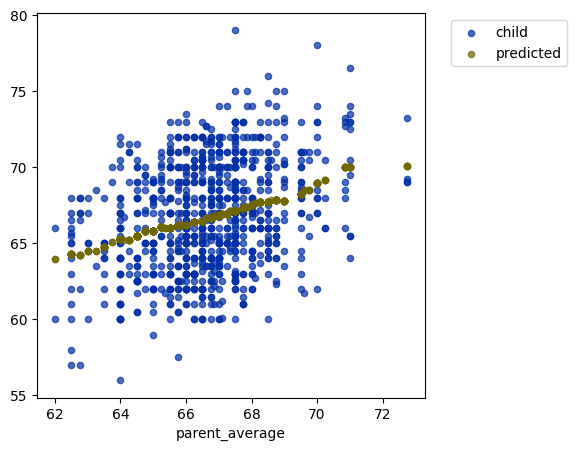

In [100]:
(
    heights
    .select("parent_average", "child", "predicted")
    .scatter("parent_average")
)

In [101]:
def error(predicted, true_value):
    return predicted - true_value

In [102]:
heights = heights.with_column("error", heights.apply(error, "predicted", "child"))

In [103]:
heights

family,father,mother,child,children,order,sex,parent_average,predicted,error
1,78.5,67,73.2,4,1,male,72.75,70.1,-3.1
1,78.5,67,69.2,4,2,female,72.75,70.1,0.9
1,78.5,67,69,4,3,female,72.75,70.1,1.1
1,78.5,67,69,4,4,female,72.75,70.1,1.1
2,75.5,66.5,73.5,4,1,male,71,69.9971,-3.50286
2,75.5,66.5,72.5,4,2,male,71,69.9971,-2.50286
2,75.5,66.5,65.5,4,3,female,71,69.9971,4.49714
2,75.5,66.5,65.5,4,4,female,71,69.9971,4.49714
3,75,64,71,2,1,male,69.5,68.2092,-2.79083
3,75,64,68,2,2,female,69.5,68.2092,0.209174


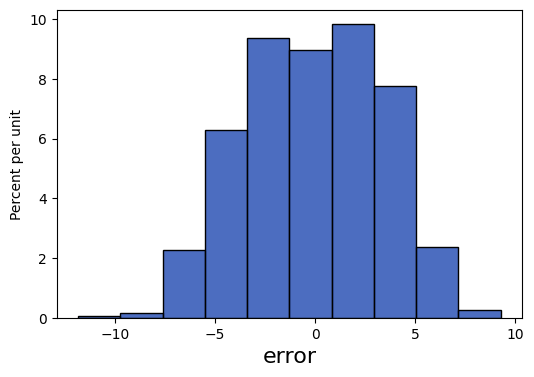

In [104]:
heights.hist("error")

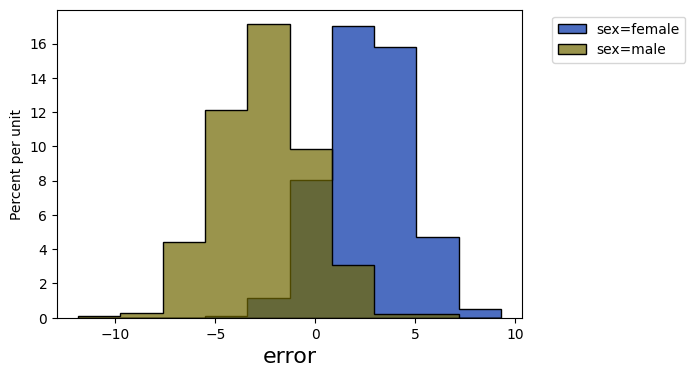

In [105]:
heights.hist("error", group="sex")

In [106]:
def predict_heights_child(parent_average, sex):
    lower_bound = parent_average - window
    upper_bound = parent_average + window
    return (
       np.mean(heights
        .where("parent_average", are.between(lower_bound, upper_bound))
        .where("sex", sex)
        .column("child")
       )
    )

In [107]:
predict_heights_child(our_average, "male")

70.640298507462674

In [108]:
predict_heights_child(our_average, "female")

65.358974358974365

In [109]:
heights = heights.with_column("prediction_with_sex", heights.apply(predict_heights_child, "parent_average", "sex"))
heights

family,father,mother,child,children,order,sex,parent_average,predicted,error,prediction_with_sex
1,78.5,67,73.2,4,1,male,72.75,70.1,-3.1,73.2
1,78.5,67,69.2,4,2,female,72.75,70.1,0.9,69.0667
1,78.5,67,69,4,3,female,72.75,70.1,1.1,69.0667
1,78.5,67,69,4,4,female,72.75,70.1,1.1,69.0667
2,75.5,66.5,73.5,4,1,male,71,69.9971,-3.50286,72.7882
2,75.5,66.5,72.5,4,2,male,71,69.9971,-2.50286,72.7882
2,75.5,66.5,65.5,4,3,female,71,69.9971,4.49714,67.3611
2,75.5,66.5,65.5,4,4,female,71,69.9971,4.49714,67.3611
3,75,64,71,2,1,male,69.5,68.2092,-2.79083,70.9566
3,75,64,68,2,2,female,69.5,68.2092,0.209174,65.6089


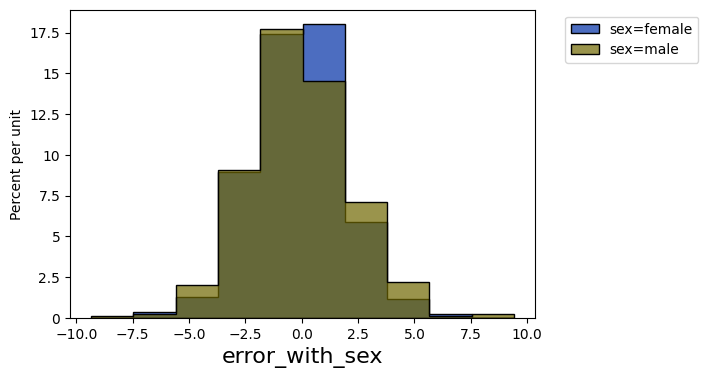

In [110]:
heights = heights.with_column("error_with_sex", heights.apply(error, "prediction_with_sex", "child"))
heights.hist("error_with_sex", group="sex")

In [111]:
heights

family,father,mother,child,children,order,sex,parent_average,predicted,error,prediction_with_sex,error_with_sex
1,78.5,67,73.2,4,1,male,72.75,70.1,-3.1,73.2,0
1,78.5,67,69.2,4,2,female,72.75,70.1,0.9,69.0667,-0.133333
1,78.5,67,69,4,3,female,72.75,70.1,1.1,69.0667,0.0666667
1,78.5,67,69,4,4,female,72.75,70.1,1.1,69.0667,0.0666667
2,75.5,66.5,73.5,4,1,male,71,69.9971,-3.50286,72.7882,-0.711765
2,75.5,66.5,72.5,4,2,male,71,69.9971,-2.50286,72.7882,0.288235
2,75.5,66.5,65.5,4,3,female,71,69.9971,4.49714,67.3611,1.86111
2,75.5,66.5,65.5,4,4,female,71,69.9971,4.49714,67.3611,1.86111
3,75,64,71,2,1,male,69.5,68.2092,-2.79083,70.9566,-0.0433962
3,75,64,68,2,2,female,69.5,68.2092,0.209174,65.6089,-2.39107


In [112]:
heights.group("sex", collect=np.mean)

sex,family mean,father mean,mother mean,child mean,children mean,order mean,parent_average mean,predicted mean,error mean,prediction_with_sex mean,error_with_sex mean
female,,69.2603,64.1488,64.104,6.34437,4.99558,66.7045,66.7127,2.60873,64.0303,-0.0736862
male,,69.1376,64.0333,69.2341,6.00832,2.2578,66.5854,66.6397,-2.59438,69.1455,-0.0885787


In [113]:
cones = Table.read_table("cones.csv")
cones

Flavor,Color,Price
strawberry,pink,3.55
chocolate,light brown,4.75
chocolate,dark brown,5.25
strawberry,pink,5.25
chocolate,dark brown,5.25
bubblegum,pink,4.75


In [114]:
cones.group("Flavor")

Flavor,count
bubblegum,1
chocolate,3
strawberry,2


In [115]:
cones.group("Flavor",collect=np.mean).select("Flavor", "Price mean")

Flavor,Price mean
bubblegum,4.75
chocolate,5.08333
strawberry,4.4


In [116]:
cones.select("Flavor", "Price").group("Flavor", collect=np.min)

Flavor,Price min
bubblegum,4.75
chocolate,4.75
strawberry,3.55


In [117]:
survey = Table.read_table("welcome_survey_sp22.csv")
survey.show(5)

Year,Extroversion,Number of textees,Hours of sleep,Handedness,Pant leg,Sleep position,Pets,Piercings
Second,5,5,8,Left-handed,Left leg in first,On your left side,Ants,0
Fourth,2,3,7,Right-handed,Left leg in first,On your left side,"Beetles, Centipedes, Scorpions",0
First,3,4,8,Right-handed,Right leg in first,On your back,Bird,0
Second,4,8,8,Right-handed,Right leg in first,On your back,Bird,0
Second,4,2,6,Right-handed,Right leg in first,On your right side,Bird,0


In [118]:
survey.select("Extroversion", "Number of textees", "Hours of sleep", "Piercings").group("Extroversion", collect=np.mean)

Extroversion,Number of textees mean,Hours of sleep mean,Piercings mean
1,2.08696,7.32609,0.478261
2,3.21951,7.30488,0.95122
3,4.71338,7.17516,1.57962
4,4.96653,7.25941,1.7113
5,5.39796,7.06888,1.45408
6,5.8141,7.125,1.83974
7,8.15721,7.04367,2.06987
8,7.95475,7.07692,2
9,10.7778,7.15741,2.88889
10,13.037,7.16667,1.92593


In [119]:
survey.group(["Handedness", "Sleep position"])

Handedness,Sleep position,count
Both,On your back,2
Both,On your left side,1
Both,On your right side,3
Both,On your stomach,3
Left-handed,On your back,15
Left-handed,On your left side,30
Left-handed,On your right side,31
Left-handed,On your stomach,17
Right-handed,On your back,299
Right-handed,On your left side,315
